<a href="https://colab.research.google.com/github/mohitgoyal1409/machine_learning/blob/main/61_adaboost_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

df = pd. DataFrame()

df['X1' ] = [1,2,3,4, 5, 6, 6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [ ]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

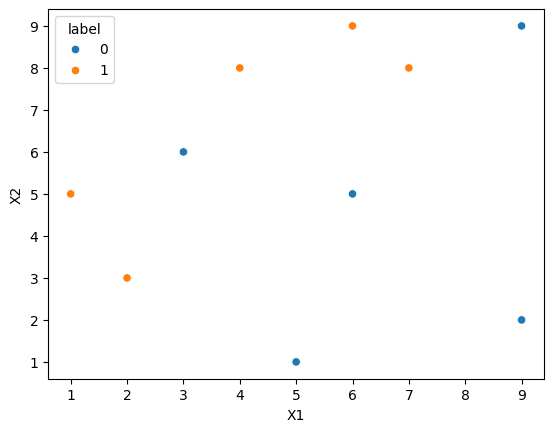

In [ ]:
import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [ ]:
df['weights'] = 1/df.shape[0]

In [ ]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [ ]:
from sklearn. tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:,0:2].values
y = df.iloc[:,2]. values

# Step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

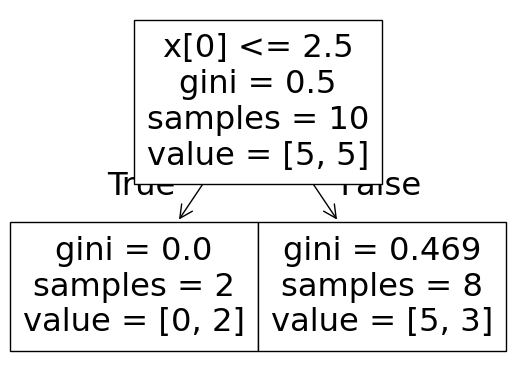

In [ ]:
from sklearn. tree import plot_tree
plot_tree(dt1)

In [ ]:
df['y_pred'] =dt1.predict(X)

In [ ]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [ ]:
def calculate_model_weight(error):

    return 0.5*np.log((1-error)/(error))


# Step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [ ]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
      if row['label'] == row['y_pred']:
        return row['weights'] * np. exp(-alpha)
      else:
        return row['weights'] * np. exp(alpha)

df['updated_weights'] = df.apply(update_row_weights, axis=1)

In [ ]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [ ]:
df['updated_weights'].sum()

np.float64(0.9165153319682015)

In [ ]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [ ]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [ ]:
df['normalized_weights'].sum()

np.float64(1.0)

In [ ]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']
df[['X1', 'X2', 'label', 'weights', 'y_pred', 'updated_weights', 'cumsum_lower', 'cumsum_upper' ]]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [ ]:
def create_new_dataset(df):

    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper' ] > a and a > row['cumsum_lower']:
              indices.append(index)
    return indices

In [ ]:
index_value = create_new_dataset(df)
index_value

[3, 7, 3, 7, 5, 5, 1, 1, 8, 9]

In [ ]:
second_df = df.iloc[index_value, [0,1,2,3]]

second_df

,X1,X2,label,weights
3,4,8,1,0.1
7,7,8,1,0.1
3,4,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1
5,6,9,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [ ]:
dt2 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df. iloc[ :, 2].values

In [ ]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 8.0\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.625, 0.5, '  False')]

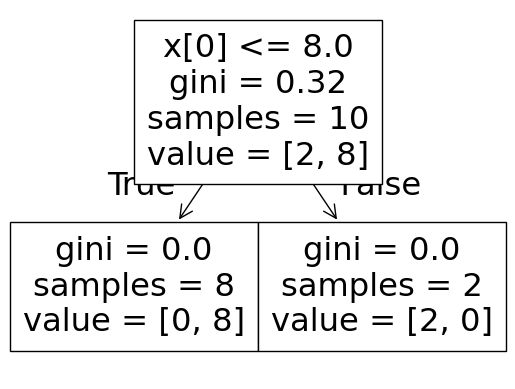

In [ ]:
plot_tree(dt2)

In [ ]:
second_df['y_pred'] = dt2.predict(X)

In [ ]:
second_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,1
7,7,8,1,0.1,1
3,4,8,1,0.1,1
7,7,8,1,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
8,9,9,0,0.1,0
9,9,2,0,0.1,0


<Axes: >

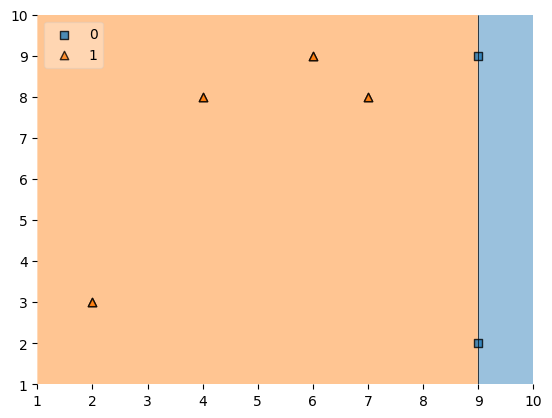

In [ ]:
plot_decision_regions(X, y, clf= dt2, legend=2)

In [ ]:
def calculate_model_weight(error):

    return 0.5*np.log((1-(error+0.00001))/(error+0.00001))


# Step 3 - calculate model weight
alpha2 = calculate_model_weight(0)
alpha2

np.float64(5.756457732460114)

In [ ]:
# Step 4 - Update weights
def update_row_weights(row,alpha=5.75):
      if row['label'] == row['y_pred']:
          return row['weights'] * np. exp(-alpha)
      else:
          return row['weights' ] * np. exp(alpha)

second_df['updated_weights'] = second_df.apply(update_row_weights, axis=1)

second_df

,X1,X2,label,weights,y_pred,updated_weights
3,4,8,1,0.1,1,0.000318
7,7,8,1,0.1,1,0.000318
3,4,8,1,0.1,1,0.000318
7,7,8,1,0.1,1,0.000318
5,6,9,1,0.1,1,0.000318
5,6,9,1,0.1,1,0.000318
1,2,3,1,0.1,1,0.000318
1,2,3,1,0.1,1,0.000318
8,9,9,0,0.1,0,0.000318
9,9,2,0,0.1,0,0.000318


In [ ]:
second_df['updated_weights'].sum()

np.float64(0.0031827807965096673)

In [ ]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
3,4,8,1,0.1,1,0.000318,0.1
7,7,8,1,0.1,1,0.000318,0.1
3,4,8,1,0.1,1,0.000318,0.1
7,7,8,1,0.1,1,0.000318,0.1
5,6,9,1,0.1,1,0.000318,0.1
5,6,9,1,0.1,1,0.000318,0.1
1,2,3,1,0.1,1,0.000318,0.1
1,2,3,1,0.1,1,0.000318,0.1
8,9,9,0,0.1,0,0.000318,0.1
9,9,2,0,0.1,0,0.000318,0.1


In [ ]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [ ]:
second_df['cumsum_upper' ] = np. cumsum(second_df['nomalized_weights'])

second_df['cumsum_lower' ] = second_df['cumsum_upper'] - second_df['nomalized_weights']

second_df[['X1', 'X2', 'label', 'weights', 'y_pred', 'nomalized_weights', 'cumsum_lower', 'cumsum_upper' ]]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
3,4,8,1,0.1,1,0.1,0.0,0.1
7,7,8,1,0.1,1,0.1,0.1,0.2
3,4,8,1,0.1,1,0.1,0.2,0.3
7,7,8,1,0.1,1,0.1,0.3,0.4
5,6,9,1,0.1,1,0.1,0.4,0.5
5,6,9,1,0.1,1,0.1,0.5,0.6
1,2,3,1,0.1,1,0.1,0.6,0.7
1,2,3,1,0.1,1,0.1,0.7,0.8
8,9,9,0,0.1,0,0.1,0.8,0.9
9,9,2,0,0.1,0,0.1,0.9,1.0


In [ ]:
index_values = create_new_dataset(second_df)

third_df = second_df. iloc[index_values, [0,1,2,3]]

third_df

,X1,X2,label,weights
8,9,9,0,0.1
5,6,9,1,0.1
5,6,9,1,0.1
1,2,3,1,0.1
7,7,8,1,0.1
7,7,8,1,0.1
1,2,3,1,0.1
1,2,3,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1


In [ ]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df. iloc[ :, 2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

In [ ]:
third_df['y_pred' ] = dt3.predict(X)

third_df

,X1,X2,label,weights,y_pred
8,9,9,0,0.1,1
5,6,9,1,0.1,1
5,6,9,1,0.1,1
1,2,3,1,0.1,1
7,7,8,1,0.1,1
7,7,8,1,0.1,1
1,2,3,1,0.1,1
1,2,3,1,0.1,1
5,6,9,1,0.1,0
7,7,8,1,0.1,0


In [ ]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)



array([1])

In [ ]:
dt2.predict(query)

array([1])

In [ ]:
alpha1*1 + alpha2*1

np.float64(6.180106662653716)

In [ ]:
np.sign(6.18)

np.float64(1.0)